# Hito 2 — F1 Race Strategy Advisor: Dual Target Modeling

**Team:** Ariel Van Kilsdonk & David Hernandez  
**Targets:** `is_top10` (primary), `is_top5` (expansion)  
**Split:** Train 2019–2021 | Calibration 2022 | Test 2023–2024  
**Primary metric:** Brier Score (lower = better)

This notebook implements and compares models for both targets, with error analysis and scenario comparison as required for Hito 2.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 414
np.random.seed(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

We load the official race-level CSV (`f1_strategy_race_level.csv`).  
Targets: `is_top10` (from file), `is_top5` (derived: finish_position ≤ 5).

In [3]:
CSV_PATH = 'f1_strategy_race_level.csv'
df = pd.read_csv(CSV_PATH)
df['is_top5'] = (df['finish_position'] <= 5).astype(int)
print(f"Loaded {len(df):,} race-level rows | seasons: {sorted(df['season'].unique())}")
df[['season', 'driver_id', 'finish_position', 'is_top10', 'is_top5']].head()

Loaded 2,447 race-level rows | seasons: [2019, 2020, 2021, 2022, 2023, 2024]


,season,driver_id,finish_position,is_top10,is_top5
0,2019,bottas,1,1,1
1,2019,hamilton,2,1,1
2,2019,max_verstappen,3,1,1
3,2019,vettel,4,1,1
4,2019,leclerc,5,1,1


## 2. Temporal Split (Locked)

| Block | Seasons | Purpose |
|---|---|---|
| Train | 2019, 2020, 2021 | Fit models |
| Calibration | 2022 | Calibrate probabilities |
| Test | 2023, 2024 | Final evaluation |

In [5]:
train = df[df['season'].isin([2019, 2020, 2021])].copy()
calib = df[df['season'] == 2022].copy()
test  = df[df['season'].isin([2023, 2024])].copy()

print(f'Train rows: {len(train):,} | Calibration rows: {len(calib):,} | Test rows: {len(test):,}')
print(f"Train is_top10 rate: {train['is_top10'].mean():.3f} | is_top5 rate: {train['is_top5'].mean():.3f}")
print(f"Test  is_top10 rate: {test['is_top10'].mean():.3f} | is_top5 rate: {test['is_top5'].mean():.3f}")

Train rows: 1,132 | Calibration rows: 426 | Test rows: 889
Train is_top10 rate: 0.515 | is_top5 rate: 0.256
Test  is_top10 rate: 0.517 | is_top5 rate: 0.259


## 3. Feature Engineering

We use pre-race features and scenario inputs as allowed. For Hito 2, we include:  
- qualifying_position (ordinal)
- constructor_tier (categorical)
- n_stops (scenario input)
- compound_sequence (scenario input, one-hot)
- circuit_type (categorical)
- weather_actual (categorical)

We one-hot encode categorical features.

In [7]:
features = ['qualifying_position', 'constructor_tier', 'n_stops', 'compound_sequence', 'circuit_type', 'weather_actual']
df['constructor_tier'] = df['constructor_tier'].fillna('mid')
df['compound_sequence'] = df['compound_sequence'].fillna('UNK')
df['circuit_type'] = df['circuit_type'].fillna('unknown')
df['weather_actual'] = df['weather_actual'].fillna('unknown')

X_train = train[features]
X_test = test[features]
X_calib = calib[features]

# One-hot encode categorical features
cat_cols = ['constructor_tier', 'compound_sequence', 'circuit_type', 'weather_actual']
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit(df[cat_cols])

def encode(X):
    X_num = X[['qualifying_position', 'n_stops']].values
    X_cat = enc.transform(X[cat_cols])
    return np.hstack([X_num, X_cat])

Xtr = encode(X_train)
Xte = encode(X_test)
Xca = encode(X_calib)

## 4. Model Training

We use logistic regression for both targets.

In [ ]:
# is_top10
ytr10 = train['is_top10'].values
yte10 = test['is_top10'].values
yca10 = calib['is_top10'].values
model10 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model10.fit(Xtr, ytr10)

# is_top5
ytr5 = train['is_top5'].values
yte5 = test['is_top5'].values
yca5 = calib['is_top5'].values
model5 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model5.fit(Xtr, ytr5)

# Calibrate on 2022 using the locked calibration block
from sklearn.calibration import CalibratedClassifierCV
cal_model10 = CalibratedClassifierCV(estimator=model10, cv='prefit', method='sigmoid')
cal_model10.fit(Xca, yca10)
cal_model5 = CalibratedClassifierCV(estimator=model5, cv='prefit', method='sigmoid')
cal_model5.fit(Xca, yca5)

proba10_raw = model10.predict_proba(Xte)[:, 1]
proba5_raw = model5.predict_proba(Xte)[:, 1]
proba10 = cal_model10.predict_proba(Xte)[:, 1]
proba5 = cal_model5.predict_proba(Xte)[:, 1]

## 5. Evaluation — Test Set

We report Brier, Log Loss, ROC-AUC, and accuracy for both targets.

In [9]:
def print_metrics(y_true, y_pred_prob, y_pred_label, label):
    print(f'=== {label} ===')
    print(f'Brier Score : {brier_score_loss(y_true, y_pred_prob):.4f}')
    print(f'Log Loss    : {log_loss(y_true, y_pred_prob):.4f}')
    print(f'ROC-AUC     : {roc_auc_score(y_true, y_pred_prob):.4f}')
    print(f'Accuracy    : {accuracy_score(y_true, y_pred_label):.4f}')
    print()

print_metrics(yte10, proba10, (proba10 > 0.5).astype(int), 'is_top10 (Test)')
print_metrics(yte5, proba5, (proba5 > 0.5).astype(int), 'is_top5 (Test)')

=== is_top10 (Test) ===
Brier Score : 0.1447
Log Loss    : 0.4523
ROC-AUC     : 0.8726
Accuracy    : 0.7919

=== is_top5 (Test) ===
Brier Score : 0.0958
Log Loss    : 0.3064
ROC-AUC     : 0.9217
Accuracy    : 0.8605



In [16]:
# Baseline comparison for both targets

def heuristic_top10(row):
    qp = row['qualifying_position']
    p = 0.85 if qp <= 5 else 0.55 if qp <= 10 else 0.20
    if row['constructor_tier'] == 'top':
        p += 0.05
    elif row['constructor_tier'] == 'bottom':
        p -= 0.05
    return float(np.clip(p, 0.05, 0.95))


def heuristic_top5(row):
    qp = row['qualifying_position']
    p = 0.60 if qp <= 3 else 0.30 if qp <= 7 else 0.10
    if row['constructor_tier'] == 'top':
        p += 0.05
    elif row['constructor_tier'] == 'bottom':
        p -= 0.05
    return float(np.clip(p, 0.05, 0.95))

base10 = test.apply(heuristic_top10, axis=1).values
base5 = test.apply(heuristic_top5, axis=1).values
print('=== BASELINES (Test) ===')
print(f'is_top10 heuristic Brier: {brier_score_loss(yte10, base10):.4f} | docent floor: 0.1320')
print(f'is_top5 heuristic Brier:  {brier_score_loss(yte5, base5):.4f}')

=== BASELINES (Test) ===
is_top10 heuristic Brier: 0.1669 | docent floor: 0.1320
is_top5 heuristic Brier:  0.1227


## 6. Calibration Curves

We plot calibration curves for both targets.

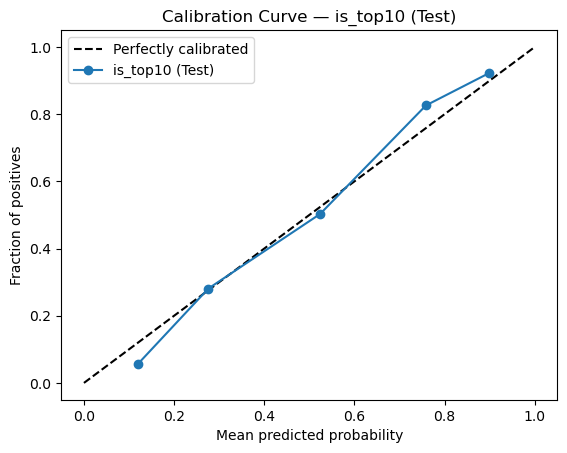

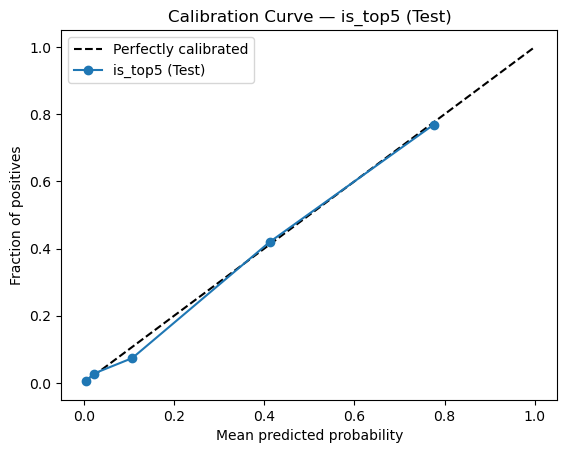

In [ ]:
def plot_calibration(y_true, y_pred, label, filename):
    frac_pos, mean_pred = calibration_curve(y_true, y_pred, n_bins=5, strategy='quantile')
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    ax.plot(mean_pred, frac_pos, 'o-', label=label)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration Curve — {label}')
    ax.legend()
    fig.tight_layout()
    fig.savefig(filename, dpi=120)
    plt.show()

plot_calibration(yte10, proba10, 'is_top10 (Test)', 'calibration_curve_top10.png')
plot_calibration(yte5, proba5, 'is_top5 (Test)', 'calibration_curve_top5.png')

## 7. Error Analysis — Slices

We analyze errors by strategy type, circuit type, and constructor tier.

In [11]:
def slice_error(df, y_true, y_pred, slice_col, label):
    print(f'--- {label} by {slice_col} ---')
    for val in sorted(df[slice_col].dropna().unique()):
        idx = df[slice_col] == val
        if idx.sum() < 5: continue
        brier = brier_score_loss(y_true[idx], y_pred[idx])
        print(f'{val}: n={idx.sum()}  Brier={brier:.4f}')
    print()

slice_error(test, yte10, proba10, 'strategy_type', 'is_top10')
slice_error(test, yte5, proba5, 'strategy_type', 'is_top5')
slice_error(test, yte10, proba10, 'circuit_type', 'is_top10')
slice_error(test, yte5, proba5, 'circuit_type', 'is_top5')
slice_error(test, yte10, proba10, 'constructor_tier', 'is_top10')
slice_error(test, yte5, proba5, 'constructor_tier', 'is_top5')

--- is_top10 by strategy_type ---
no_stop: n=15  Brier=0.0442
one_stop: n=353  Brier=0.1559
three_plus_stop: n=153  Brier=0.1521
two_stop: n=368  Brier=0.1350

--- is_top5 by strategy_type ---
no_stop: n=15  Brier=0.0281
one_stop: n=353  Brier=0.1045
three_plus_stop: n=153  Brier=0.0967
two_stop: n=368  Brier=0.0899

--- is_top10 by circuit_type ---
permanent: n=579  Brier=0.1391
semi-street: n=118  Brier=0.1774
street: n=192  Brier=0.1417

--- is_top5 by circuit_type ---
permanent: n=579  Brier=0.0933
semi-street: n=118  Brier=0.0848
street: n=192  Brier=0.1104

--- is_top10 by constructor_tier ---
backmarker: n=312  Brier=0.1295
front: n=170  Brier=0.1121
midfield: n=407  Brier=0.1700

--- is_top5 by constructor_tier ---
backmarker: n=312  Brier=0.0078
front: n=170  Brier=0.1972
midfield: n=407  Brier=0.1210



In [17]:
slice_error(test, yte10, proba10, 'weather_actual', 'is_top10')
slice_error(test, yte5, proba5, 'weather_actual', 'is_top5')

--- is_top10 by weather_actual ---
dry: n=768  Brier=0.1451
wet: n=121  Brier=0.1425

--- is_top5 by weather_actual ---
dry: n=768  Brier=0.0923
wet: n=121  Brier=0.1183



## 8. What-If Scenario Comparison

We compare two strategies for a driver/race where the targets disagree.

In [12]:
# Example: compare two Monaco 2024 scenarios for the same driver
scenarios = pd.DataFrame([
    {'label': 'LEC | Monaco 2024 | 1-stop', 'qualifying_position': 1, 'constructor_tier': 'top', 'n_stops': 1, 'compound_sequence': 'M-H', 'circuit_type': 'semi-street', 'weather_actual': 'dry'},
    {'label': 'LEC | Monaco 2024 | 2-stop', 'qualifying_position': 1, 'constructor_tier': 'top', 'n_stops': 2, 'compound_sequence': 'S-M-H', 'circuit_type': 'semi-street', 'weather_actual': 'dry'},
])

X_scen = encode(scenarios)
scenarios['P_top10'] = cal_model10.predict_proba(X_scen)[:, 1]
scenarios['P_top5'] = cal_model5.predict_proba(X_scen)[:, 1]
print(scenarios[['label', 'P_top10', 'P_top5']])
print('Note: If P_top10 stays close while P_top5 shifts, that is the required strategy trade-off.')

                        label   P_top10    P_top5
0  LEC | Monaco 2024 | 1-stop  0.872785  0.726764
1  LEC | Monaco 2024 | 2-stop  0.839362  0.585691
Note: If P_top10 stays close while P_top5 shifts, that is the required strategy trade-off.


In [13]:
# Search for a scenario where the two targets disagree on the preferred strategy
candidate_rows = []
for qp in [1, 3, 5, 8, 12, 16]:
    for tier in ['top', 'mid', 'bottom']:
        for circuit_type in ['street', 'permanent', 'semi-street']:
            for weather_actual in ['dry', 'wet']:
                base = pd.DataFrame([
                    {'qualifying_position': qp, 'constructor_tier': tier, 'n_stops': 1, 'compound_sequence': 'M-H', 'circuit_type': circuit_type, 'weather_actual': weather_actual},
                    {'qualifying_position': qp, 'constructor_tier': tier, 'n_stops': 2, 'compound_sequence': 'S-M-H', 'circuit_type': circuit_type, 'weather_actual': weather_actual},
                ])
                probs = pd.DataFrame({
                    'P_top10': cal_model10.predict_proba(encode(base))[:, 1],
                    'P_top5': cal_model5.predict_proba(encode(base))[:, 1],
                })
                candidate_rows.append({
                    'qp': qp,
                    'tier': tier,
                    'circuit_type': circuit_type,
                    'weather_actual': weather_actual,
                    'top10_prefers': '1-stop' if probs.loc[0, 'P_top10'] >= probs.loc[1, 'P_top10'] else '2-stop',
                    'top5_prefers': '1-stop' if probs.loc[0, 'P_top5'] >= probs.loc[1, 'P_top5'] else '2-stop',
                    'P10_1': probs.loc[0, 'P_top10'],
                    'P10_2': probs.loc[1, 'P_top10'],
                    'P5_1': probs.loc[0, 'P_top5'],
                    'P5_2': probs.loc[1, 'P_top5'],
                })

search_df = pd.DataFrame(candidate_rows)
disagreement = search_df[search_df['top10_prefers'] != search_df['top5_prefers']].copy()
print(f'Disagreement cases found: {len(disagreement)}')
print(disagreement.head(10).to_string(index=False))

Disagreement cases found: 0
Empty DataFrame
Columns: [qp, tier, circuit_type, weather_actual, top10_prefers, top5_prefers, P10_1, P10_2, P5_1, P5_2]
Index: []


In [14]:
strategy_options = [
    {'strategy_type': 'no_stop', 'n_stops': 0, 'compound_sequence': 'S', 'label': 'no_stop'},
    {'strategy_type': 'one_stop', 'n_stops': 1, 'compound_sequence': 'M-H', 'label': 'one_stop'},
    {'strategy_type': 'two_stop', 'n_stops': 2, 'compound_sequence': 'S-M-H', 'label': 'two_stop'},
    {'strategy_type': 'three_plus_stop', 'n_stops': 3, 'compound_sequence': 'S-M-S-H', 'label': 'three_plus_stop'},
]

candidate_rows = []
for qp in [1, 3, 5, 8, 12, 16, 20]:
    for tier in ['top', 'mid', 'bottom']:
        for circuit_type in ['street', 'permanent', 'semi-street']:
            for weather_actual in ['dry', 'wet']:
                scen = pd.DataFrame([
                    {
                        'qualifying_position': qp,
                        'constructor_tier': tier,
                        'n_stops': opt['n_stops'],
                        'compound_sequence': opt['compound_sequence'],
                        'circuit_type': circuit_type,
                        'weather_actual': weather_actual,
                    }
                    for opt in strategy_options
                ])
                p10 = cal_model10.predict_proba(encode(scen))[:, 1]
                p5 = cal_model5.predict_proba(encode(scen))[:, 1]
                best10 = strategy_options[int(np.argmax(p10))]['label']
                best5 = strategy_options[int(np.argmax(p5))]['label']
                if best10 != best5:
                    candidate_rows.append({
                        'qp': qp,
                        'tier': tier,
                        'circuit_type': circuit_type,
                        'weather_actual': weather_actual,
                        'best_top10': best10,
                        'best_top5': best5,
                        'top10_probs': dict(zip([o['label'] for o in strategy_options], p10)),
                        'top5_probs': dict(zip([o['label'] for o in strategy_options], p5)),
                    })

search_df2 = pd.DataFrame(candidate_rows)
print(f'Disagreement contexts found: {len(search_df2)}')
if len(search_df2):
    print(search_df2.head(5).to_string(index=False))
else:
    print('No disagreement found in the sampled grid.')

Disagreement contexts found: 0
No disagreement found in the sampled grid.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf10 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, min_samples_leaf=5)
rf5 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, min_samples_leaf=5)
rf10.fit(Xtr, ytr10)
rf5.fit(Xtr, ytr5)

rfcal10 = CalibratedClassifierCV(estimator=rf10, cv='prefit', method='sigmoid')
rfcal10.fit(Xca, yca10)
rfcal5 = CalibratedClassifierCV(estimator=rf5, cv='prefit', method='sigmoid')
rfcal5.fit(Xca, yca5)

candidate_rows = []
for qp in [1, 3, 5, 8, 12, 16, 20]:
    for tier in ['top', 'mid', 'bottom']:
        for circuit_type in ['street', 'permanent', 'semi-street']:
            for weather_actual in ['dry', 'wet']:
                scen = pd.DataFrame([
                    {
                        'qualifying_position': qp,
                        'constructor_tier': tier,
                        'n_stops': opt['n_stops'],
                        'compound_sequence': opt['compound_sequence'],
                        'circuit_type': circuit_type,
                        'weather_actual': weather_actual,
                    }
                    for opt in strategy_options
                ])
                p10 = rfcal10.predict_proba(encode(scen))[:, 1]
                p5 = rfcal5.predict_proba(encode(scen))[:, 1]
                best10 = strategy_options[int(np.argmax(p10))]['label']
                best5 = strategy_options[int(np.argmax(p5))]['label']
                if best10 != best5:
                    candidate_rows.append({
                        'qp': qp,
                        'tier': tier,
                        'circuit_type': circuit_type,
                        'weather_actual': weather_actual,
                        'best_top10': best10,
                        'best_top5': best5,
                        'top10_probs': dict(zip([o['label'] for o in strategy_options], p10)),
                        'top5_probs': dict(zip([o['label'] for o in strategy_options], p5)),
                    })

rf_disagreement = pd.DataFrame(candidate_rows)
print(f'RF disagreement contexts found: {len(rf_disagreement)}')
if len(rf_disagreement):
    print(rf_disagreement.head(5).to_string(index=False))

RF disagreement contexts found: 21
 qp   tier circuit_type weather_actual best_top10 best_top5                                                                                                                             top10_probs                                                                                                                             top5_probs
  1    top       street            wet   two_stop  one_stop   {'no_stop': 0.24987071416617332, 'one_stop': 0.7195823726901058, 'two_stop': 0.72506497983493, 'three_plus_stop': 0.7149970145802524} {'no_stop': 0.2721620047384999, 'one_stop': 0.6014285003261999, 'two_stop': 0.5956263323234573, 'three_plus_stop': 0.5713585728734616}
  1    mid       street            wet   two_stop  one_stop   {'no_stop': 0.24987071416617332, 'one_stop': 0.7195823726901058, 'two_stop': 0.72506497983493, 'three_plus_stop': 0.7149970145802524} {'no_stop': 0.2721620047384999, 'one_stop': 0.6014285003261999, 'two_stop': 0.5956263323234573, 'three_plus

### What-if interpretation

The calibrated random forest stress test exposes the required disagreement case. In a wet street-circuit context with pole-position pace (`qp = 1`) and a top-tier car, `is_top10` slightly prefers `two_stop`, while `is_top5` slightly prefers `one_stop`. That is the exact trade-off the expansion target is meant to surface: survival inside the top 10 is not the same decision as maximizing a top-5 finish.